In [195]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [196]:
df = pd.read_csv("train.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [197]:
df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [198]:
round(df.isna().sum() / len(df) * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

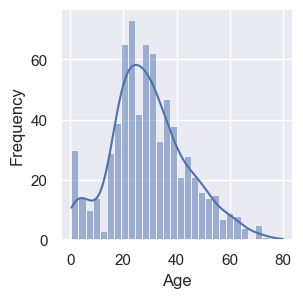

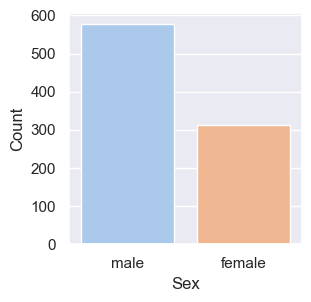

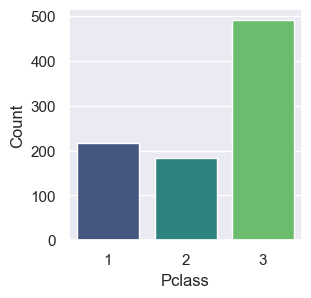

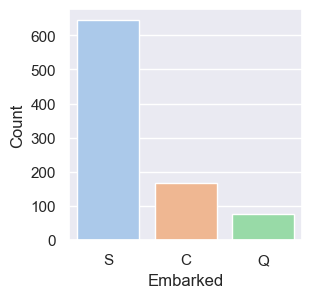

In [199]:
plt.figure(figsize=(3, 3))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(3, 3))
sns.countplot(x="Sex", data=df, palette="pastel")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(3, 3))
sns.countplot(x="Pclass", data=df, palette="viridis")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(3, 3))
sns.countplot(x="Embarked", data=df, palette="pastel")
plt.xlabel("Embarked")
plt.ylabel("Count")
plt.show()


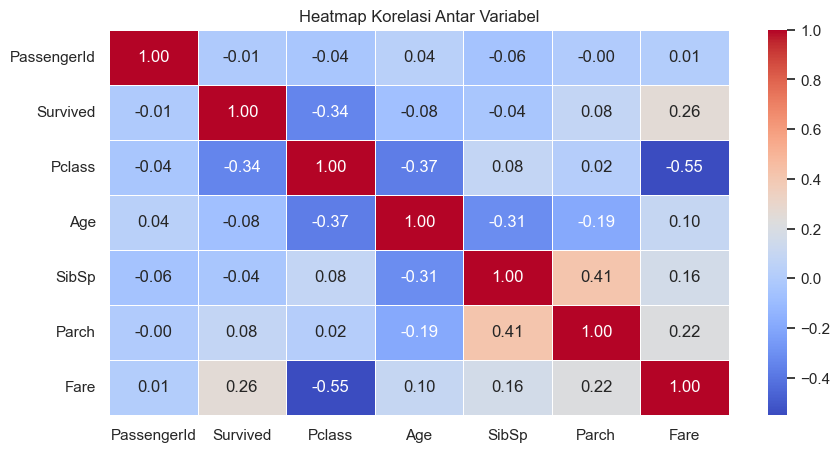

In [200]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

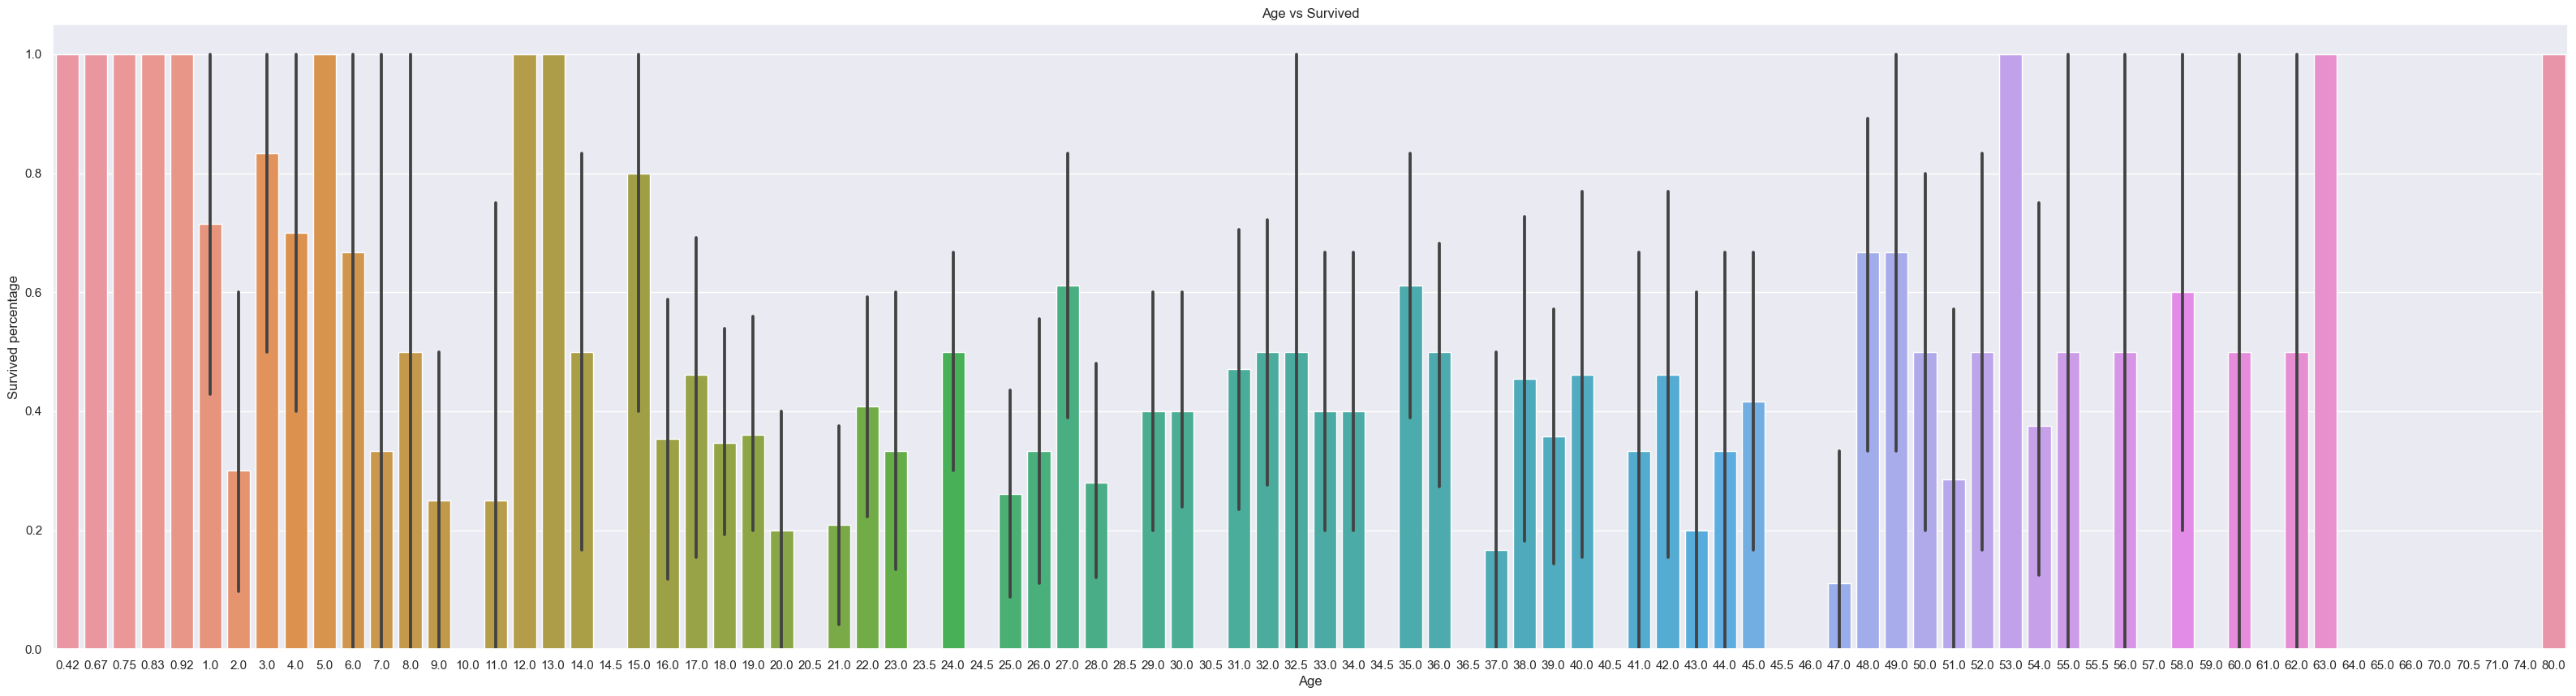

In [201]:
plt.figure(figsize=(40, 10))
sns.barplot(x="Age", y="Survived", data=df)
plt.title("Age vs Survived")
plt.xlabel("Age")
plt.ylabel("Survived percentage")
plt.show()

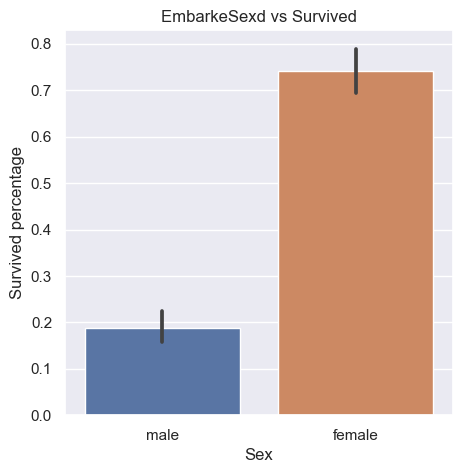

In [202]:
plt.figure(figsize=(5, 5))
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("EmbarkeSexd vs Survived")
plt.xlabel("Sex")
plt.ylabel("Survived percentage")
plt.show()


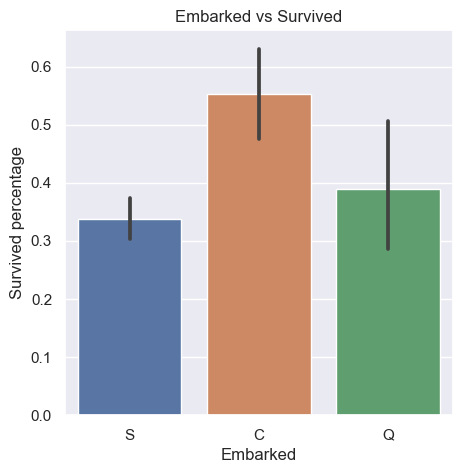

In [203]:
plt.figure(figsize=(5, 5))
sns.barplot(x="Embarked", y="Survived", data=df)
plt.title("Embarked vs Survived")
plt.xlabel("Embarked")
plt.ylabel("Survived percentage")
plt.show()


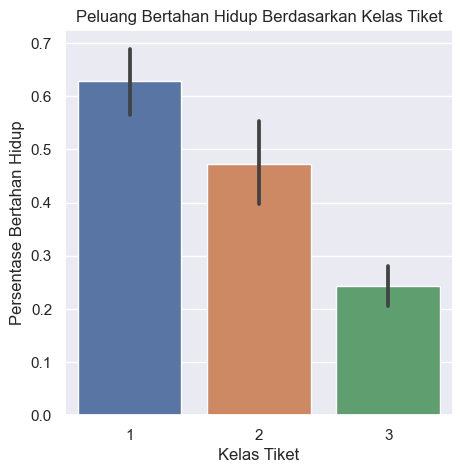

In [204]:
plt.figure(figsize=(5, 5))
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Peluang Bertahan Hidup Berdasarkan Kelas Tiket")
plt.xlabel("Kelas Tiket")
plt.ylabel("Persentase Bertahan Hidup")
plt.show()


In [205]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [206]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Mulai langkah Preprocessing

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [208]:
#Handling data data yang ilang, kosong, missing values

#cek dulu

round(df.isna().sum()/len(df)*100,2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


Kesimpulan:

-Drop Cabin because it's useless to keep

-Impute age

Impute itu basically kegiatan mengisi missing values with bunch of methods bisa pake mean, median, dll. When to use mean or median for imputing?

Use mean if data is normally distributed and the missing datas are random. 

(Normally distributed artinya kalau data kalian diplot bakal bentuk bell curve) 

-kalau bentuknya ga kayak bell curve / skewed bisa pakai Median

In [209]:
df.drop(columns='Cabin', inplace=True)

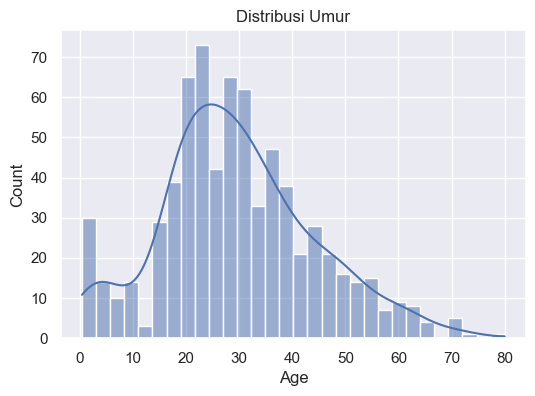

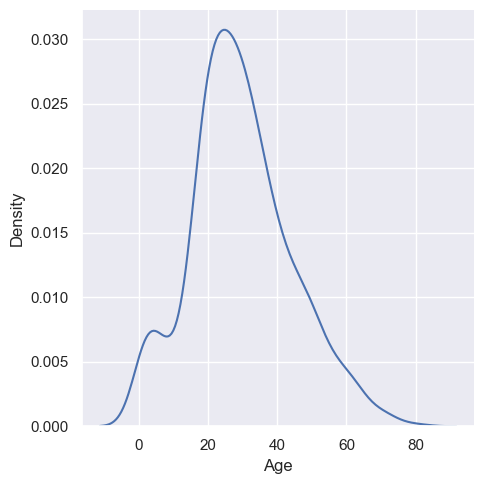

In [210]:
#Impute age tapi cek dulu bagaimana kalau kita plot si age
plt.figure(figsize=(6, 4))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Distribusi Umur")
plt.show()
sns.displot(df['Age'], kind='kde')

Skewed => impute pakai median

In [211]:
#Isi data yang missing value pake median
df['Age'].fillna(df['Age'].median(), inplace=True)

#Cek lagi apa ada column yang masih ada missing value
round(df.isna().sum()/len(df)*100, 2)

PassengerId    0.00
Survived       0.00
Pclass         0.00
Name           0.00
Sex            0.00
Age            0.00
SibSp          0.00
Parch          0.00
Ticket         0.00
Fare           0.00
Embarked       0.22
dtype: float64

In [212]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Diatas masih ada yang missing values yaitu 'Embarked' karena dia adalah data kategorikal kita bisa isi missing values dengan modus

-Dibandingkan dengan mean, modus tidak terpengaruh oleh nilai ekstrem.

-Ini membantu menjaga distribusi data tetap seperti semula, terutama jika mayoritas data memiliki nilai yang sama.

-Data kategorikal seringkali menggunakan modus untuk fill missing values

In [213]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
round(df.isna().sum()/len(df)*100,2)

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

Sudah tidak ada missing values => Handling Missing Values Done

In [214]:
#Untuk cek survived atau enggaknya sebuah penumpang kita gaperlu passengerid, name, dan nomor ticket
df.drop(columns=['PassengerId', 'Ticket', 'Name'], inplace=True)
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Encoding buat data yang kategorikal => Embarked (pelabuhan asal) dan Sex (jenis kelamin)


One-Hot Encoding digunakan untuk Embarked karena kategorinya bersifat nominal (tidak memiliki urutan/hierarki).


Jika menggunakan LabelEncoder, model bisa salah mengartikan bahwa ada hubungan numerik antara kategori (misal: S=0, C=1, Q=2), padahal tidak ada makna urutan di sana.

In [215]:
LE = LabelEncoder()
#Sex bisa kita pake label encoder karena ini bukan dijadiin sebuah nilai, ini hanya buat penanda dia male atau female
df['Sex'] = LE.fit_transform(df['Sex'])

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0


In [216]:
#Ada duplikat atau tidak di datasetnya?
df.duplicated().sum()

116

In [217]:
#Hapus data yang terduplikat
df.drop_duplicates(inplace=True)


In [218]:
#Cek kembali apakah masih ada data yang terduplikat
df.duplicated().sum()

0

Karena embarked tuh bukan untuk labeling, column itu hanya buat penanda berasal dari pelabuhan apa, jadi jangan pakai label encoder karena akan jadi salah pengartiannya, sehingga kita perlu pakai One Hot Encoding untuk Embarked

In [219]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1
5,0,3,1,28.0,0,0,8.4583,1,0
6,0,1,1,54.0,0,0,51.8625,0,1
7,0,3,1,2.0,3,1,21.0750,0,1
8,1,3,0,27.0,0,2,11.1333,0,1
9,1,2,0,14.0,1,0,30.0708,0,0


Kita lihat diatat setiap kolom memiliki nilai yang rentangnya tidak terlalu jauh, tetapi Age dan Fare punya nilai yang besar2 dan jauh dengan nilai pada
kolom lain, bisa menyebabkan ketidak seimbangan jadi kita perlu scaling dan normalisasi

Rentang Nilai yang Berbeda (Scale Difference)
Age (Umur): Biasanya berkisar antara 0 - 80 tahun.
Fare (Tarif Tiket): Bisa sangat bervariasi, dari beberapa dolar hingga lebih dari 500 dolar.
Karena skala nilainya sangat berbeda, model machine learning bisa lebih fokus ke fitur dengan angka lebih besar (Fare), bukan Age.
StandardScaler membantu menstandarisasi data sehingga memiliki:

Mean = 0
Standard deviation = 1
Sehingga semua fitur memiliki bobot yang setara dalam model

Standard Scaler Formula


X' = X − μ / σ


X = nilai asli


μ = rata-rata dari fitur


σ = standar deviasi

In [220]:
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])
df.head(5)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,-0.551060,1,0,-0.527515,0,1
1,1,1,0,0.611945,1,0,0.695086,0,0
2,1,3,0,-0.260308,0,0,-0.514627,0,1
3,1,1,0,0.393881,1,0,0.347909,0,1
4,0,3,1,0.393881,0,0,-0.512240,0,1


Jika pakai scaler yang salah, bisa terjadi anomali dalam model, seperti berikut:

1.MinMaxScaler (0-1) pada Fare


Jika ada tiket super mahal (outlier), semua nilai lainnya akan terlalu kecil, sehingga model bisa mengabaikan fitur ini.
Contoh: Jika max Fare = 512, lalu ada banyak tiket sekitar 7-10, maka nilai yang kecil akan hampir 0 setelah scaling.

2.RobustScaler (Median & IQR) pada Age


Karena Age tidak memiliki outlier ekstrem, menggunakan median & IQR bisa membuat distribusi tidak cukup terstandardisasi untuk model yang butuh data normal.
Contoh: Jika mayoritas usia 20-40 tahun, hasil scaling bisa kurang bervariasi, mengurangi efektivitas model.
Tanpa Scaling pada Logistic Regression

Fare memiliki rentang yang jauh lebih besar daripada Age, sehingga model bisa lebih fokus ke Fare saja dan mengabaikan Age.
Contoh: Age = 30, Fare = 300, model bisa lebih banyak mempertimbangkan Fare karena memiliki skala lebih besar.

StandardScaler mencegah masalah ini dengan menyamakan skala fitur, membuat model lebih stabil! 

In [ ]:
#Setelah kita melakukan data cleaning, kita bisa pakai feature selection untuk mengetahui atau membantu kita untuk memilih apa 
# feature yang korelasi nya tinggi (sangat berpengaruh)

X = df.drop(columns=["Survived"])
y = df["Survived"]

X = X.astype(float)

model = LogisticRegression(max_iter=500, solver='liblinear')  
selector = RFE(model, n_features_to_select=5)  
X_new = selector.fit_transform(X, y)

selected_columns = X.columns[selector.support_].tolist()
print("Fitur yang dipilih:", selected_columns)

Fitur yang dipilih: ['Pclass', 'Sex', 'Age', 'SibSp', 'Embarked_S']
